# Simulasi Monte Carlo Saham JSMR

## Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

## Load Data Saham JSMR (18 Bulan)

In [ ]:
# Load data 18 bulan
data_all = pd.read_csv("JSMR_18bulan.csv", skiprows=2)
data_all.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
data_all['Date'] = pd.to_datetime(data_all['Date'])
data_all = data_all.sort_values('Date').reset_index(drop=True)

print(f"Total data: {len(data_all)} hari")
print(f"Periode: {data_all['Date'].min().strftime('%Y-%m-%d')} s/d {data_all['Date'].max().strftime('%Y-%m-%d')}")
data_all.head()

Total data: 361 hari
Periode: 2024-06-03 s/d 2025-11-28


,Date,Close,High,Low,Open,Volume
0,2024-06-03,4581.666504,4658.669302,4572.041154,4600.917204,7516700
1,2024-06-04,4745.297363,4836.738185,4581.666420,4581.666420,7426400
2,2024-06-05,4812.674805,4812.674805,4726.046658,4745.297357,4273300
3,2024-06-06,4884.864746,4981.118239,4812.674627,4812.674627,12243200
4,2024-06-07,4981.118652,5005.182027,4884.865152,4884.865152,3592600


In [ ]:
# Suku bunga BI 2024 (rata-rata)
r_annual = 0.06  # 6% (sesuaikan dengan data BI tahun 2024)
r_daily = r_annual / 252

print(f"Risk-free rate tahunan: {r_annual:.2%}")
print(f"Risk-free rate harian: {r_daily:.6f}")

Risk-free rate tahunan: 6.00%
Risk-free rate harian: 0.000238


## Risk-Free Rate (Suku Bunga BI)

In [ ]:
# 12 bulan pertama untuk estimasi parameter (training)
data_train = data_all.head(260).reset_index(drop=True)

# Hitung return harian
returns = np.log(data_train['Close'] / data_train['Close'].shift(1))
returns = returns.dropna()

# Volatilitas (standar deviasi return harian)
sigma = returns.std()

# Volatilitas tahunan (252 hari bursa)
sigma_annual = sigma * np.sqrt(252)

print(f"Volatilitas harian (σ): {sigma:.6f}")
print(f"Volatilitas tahunan: {sigma_annual:.6f}")

Volatilitas harian (σ): 0.020580
Volatilitas tahunan: 0.326705


## Analisis Return Saham

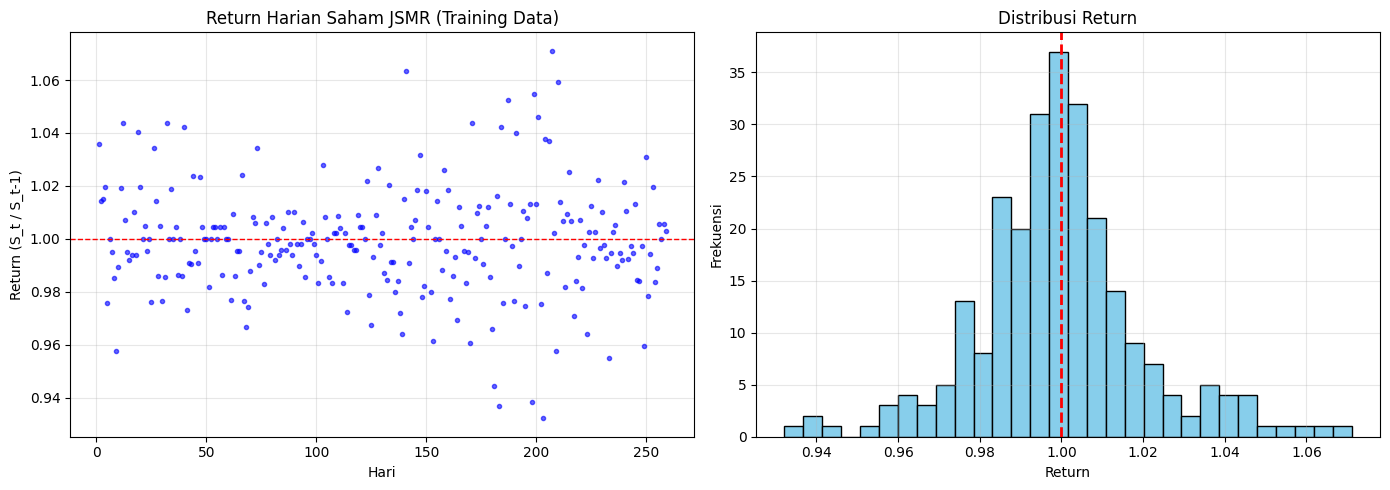

Statistik Return:
Mean return (naik): 1.016980
Std return (naik): 0.015276
Mean return (turun): 0.986821
Std return (turun): 0.013518
Probabilitas naik (empiris): 0.413127


In [ ]:
# Hitung return (faktor perubahan harga)
data_train['return'] = data_train['Close'] / data_train['Close'].shift(1)
ret = data_train['return'].dropna()

# Scatter plot return
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ret, ".", color='blue', alpha=0.6)
ax1.axhline(y=1, color='red', linestyle='--', linewidth=1)
ax1.set_title('Return Harian Saham JSMR (Training Data)')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Return (S_t / S_t-1)')
ax1.grid(True, alpha=0.3)

# Histogram return
ax2.hist(ret, bins=30, color='skyblue', edgecolor='black')
ax2.axvline(x=1, color='red', linestyle='--', linewidth=2)
ax2.set_title('Distribusi Return')
ax2.set_xlabel('Return')
ax2.set_ylabel('Frekuensi')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistik return untuk up dan down
print("Statistik Return:")
print(f"Mean return (naik): {ret[ret > 1].mean():.6f}")
print(f"Std return (naik): {ret[ret > 1].std():.6f}")
print(f"Mean return (turun): {ret[ret <= 1].mean():.6f}")
print(f"Std return (turun): {ret[ret <= 1].std():.6f}")
print(f"Probabilitas naik (empiris): {(ret > 1).sum() / len(ret):.6f}")

## Estimasi Volatilitas (σ) dari Data 12 Bulan

In [ ]:
# 12 bulan pertama untuk estimasi parameter (training)
data_train = data_all.head(260).reset_index(drop=True)

# 6 bulan terakhir untuk validasi (testing)
data_test = data_all.tail(130).reset_index(drop=True)

print(f"Data Training: {len(data_train)} hari ({data_train['Date'].min().strftime('%Y-%m-%d')} s/d {data_train['Date'].max().strftime('%Y-%m-%d')})")
print(f"Data Testing: {len(data_test)} hari ({data_test['Date'].min().strftime('%Y-%m-%d')} s/d {data_test['Date'].max().strftime('%Y-%m-%d')})")

# Harga awal dan data testing
S0 = data_test['Close'].values[0]
harga_aktual = data_test['Close'].values
N = len(harga_aktual)

print(f"\nHarga awal (S0): Rp {S0:,.2f}")
print(f"Jumlah periode simulasi (N): {N} hari")

Data Training: 260 hari (2024-06-03 s/d 2025-07-08)
Data Testing: 130 hari (2025-05-22 s/d 2025-11-28)

Harga awal (S0): Rp 4,030.00
Jumlah periode simulasi (N): 130 hari


## Split Data: 12 Bulan Training + 6 Bulan Testing

## Metode 1: Cox-Ross-Rubinstein (CRR)

In [ ]:
dt = 1/252  # time step (1 hari bursa)

# Hitung parameter CRR
u_crr = np.exp(sigma * np.sqrt(dt))
d_crr = np.exp(-sigma * np.sqrt(dt))
p_crr = (np.exp(r_daily * dt) - d_crr) / (u_crr - d_crr)

print("Parameter Model CRR:")
print(f"u (up factor): {u_crr:.6f}")
print(f"d (down factor): {d_crr:.6f}")
print(f"p (probabilitas up): {p_crr:.6f}")
print(f"Verifikasi u*d = {u_crr*d_crr:.6f} ≈ 1")

Parameter Model CRR:
u (up factor): 1.001297
d (down factor): 0.998704
p (probabilitas up): 0.500040
Verifikasi u*d = 1.000000 ≈ 1


## Visualisasi Binomial Tree

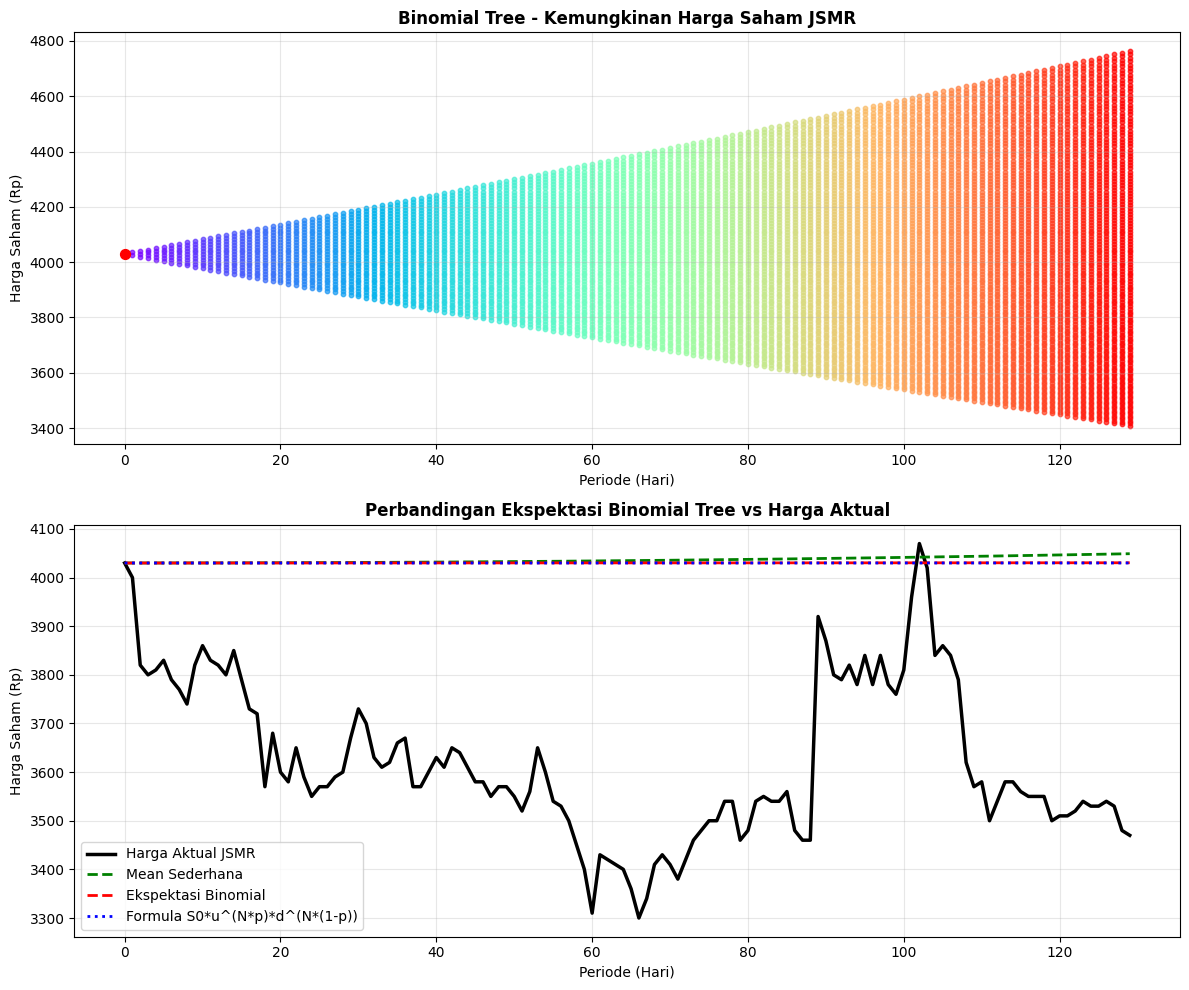


Parameter: S0=4030, u=1.0013, d=0.9987, p=0.5000

Harga akhir periode ke-129:
Harga aktual: Rp 3,470.00
Mean sederhana: Rp 4,049.10
Ekspektasi binomial: Rp 4,030.49
Formula teoretis: Rp 4,030.05


In [ ]:
# Membuat Binomial Tree untuk visualisasi
N_tree = N - 1  # Gunakan semua periode testing
price_tree = np.zeros((N_tree+1, N_tree+1), float)
mean_price = np.zeros(N_tree+1, float)
mean_expected = np.zeros(N_tree+1, float)
mean_formula = np.zeros(N_tree+1, float)

price_tree[0,0] = S0
mean_price[0] = S0
mean_expected[0] = S0
mean_formula[0] = S0

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Subplot 1: Binomial Tree
ax[0].scatter(0, price_tree[0,0], s=50, c='red', zorder=5)

# Generate warna random untuk setiap periode
import matplotlib.cm as cm
colors = cm.rainbow(np.linspace(0, 1, N_tree+1))

for i in range(1, N_tree+1):
    for j in range(i+1):
        # Hitung harga di setiap node
        price_tree[j, i] = S0 * (u_crr**j) * (d_crr**(i-j))

    # Plot semua harga di time step i dengan warna berbeda
    ax[0].scatter([i]*len(price_tree[0:i+1, i]), price_tree[0:i+1, i],
                  s=10, c=[colors[i]], alpha=0.7)

    # Hitung rata-rata sederhana
    mean_price[i] = np.mean(price_tree[0:i+1, i])

    # Hitung ekspektasi dengan probabilitas binomial
    prob = np.array([math.comb(i, j) * (p_crr**j) * ((1-p_crr)**(i-j))
                     for j in range(i+1)])
    mean_expected[i] = np.sum(price_tree[0:i+1, i] * prob)

    # Formula teoretis
    mean_formula[i] = S0 * (u_crr**(i*p_crr)) * (d_crr**(i*(1-p_crr)))

ax[0].set_title('Binomial Tree - Kemungkinan Harga Saham JSMR', fontweight='bold')
ax[0].set_xlabel('Periode (Hari)')
ax[0].set_ylabel('Harga Saham (Rp)')
ax[0].grid(True, alpha=0.3)

# Subplot 2: Perbandingan Mean vs Harga Aktual
ax[1].plot(range(N_tree+1), harga_aktual[:N_tree+1], label='Harga Aktual JSMR',
           linewidth=2.5, color='black')
ax[1].plot(range(N_tree+1), mean_price, 'g--', linewidth=2, label='Mean Sederhana')
ax[1].plot(range(N_tree+1), mean_expected, 'r--', linewidth=2, label='Ekspektasi Binomial')
ax[1].plot(range(N_tree+1), mean_formula, 'b:', linewidth=2, label='Formula S0*u^(N*p)*d^(N*(1-p))')

ax[1].set_title('Perbandingan Ekspektasi Binomial Tree vs Harga Aktual', fontweight='bold')
ax[1].set_xlabel('Periode (Hari)')
ax[1].set_ylabel('Harga Saham (Rp)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nParameter: S0={S0:.0f}, u={u_crr:.4f}, d={d_crr:.4f}, p={p_crr:.4f}")
print(f"\nHarga akhir periode ke-{N_tree}:")
print(f"Harga aktual: Rp {harga_aktual[N_tree]:,.2f}")
print(f"Mean sederhana: Rp {mean_price[N_tree]:,.2f}")
print(f"Ekspektasi binomial: Rp {mean_expected[N_tree]:,.2f}")
print(f"Formula teoretis: Rp {mean_formula[N_tree]:,.2f}")

In [ ]:
# Hitung faktor perubahan harga
f = data_train['Close'] / data_train['Close'].shift(1)
f = f.dropna()

# Estimasi u dan d
u_emp = f[f >= 1].mean()
d_emp = f[f < 1].mean()
p_emp = (f >= 1).sum() / len(f)

print("Parameter Empiris:")
print(f"u (up factor): {u_emp:.6f}")
print(f"d (down factor): {d_emp:.6f}")
print(f"p (probabilitas up): {p_emp:.6f}")
print(f"Verifikasi u*d = {u_emp*d_emp:.6f}")

Parameter Empiris:
u (up factor): 1.013869
d (down factor): 0.984350
p (probabilitas up): 0.505792
Verifikasi u*d = 0.998002


## Metode 2: Pendekatan Empiris

## Simulasi Monte Carlo - Metode CRR

In [ ]:
M = 1000  # jumlah simulasi
np.random.seed(42)

simulasi_crr = np.zeros((M, N))
mean_theoretical = np.zeros(N)

for m in range(M):
    harga = S0
    simulasi_crr[m, 0] = harga

    for t in range(1, N):
        if np.random.rand() < p_crr:
            harga *= u_crr
        else:
            harga *= d_crr
        simulasi_crr[m, t] = harga

# Hitung ekspektasi teoretis untuk setiap periode
for t in range(N):
    mean_theoretical[t] = S0 * (u_crr**(t*p_crr)) * (d_crr**(t*(1-p_crr)))

print(f"Simulasi CRR selesai: {M} simulasi x {N} periode")
print(f"Ekspektasi teoretis periode akhir: Rp {mean_theoretical[-1]:,.2f}")

Simulasi CRR selesai: 1000 simulasi x 130 periode
Ekspektasi teoretis periode akhir: Rp 4,030.05


## Simulasi Monte Carlo - Metode Empiris

In [ ]:
np.random.seed(42)

simulasi_emp = np.zeros((M, N))

for m in range(M):
    harga = S0
    simulasi_emp[m, 0] = harga

    for t in range(1, N):
        if np.random.rand() < p_emp:
            harga *= u_emp
        else:
            harga *= d_emp
        simulasi_emp[m, t] = harga

print(f"Simulasi Empiris selesai: {M} simulasi x {N} periode")

Simulasi Empiris selesai: 1000 simulasi x 130 periode


## Visualisasi Path Simulasi Monte Carlo

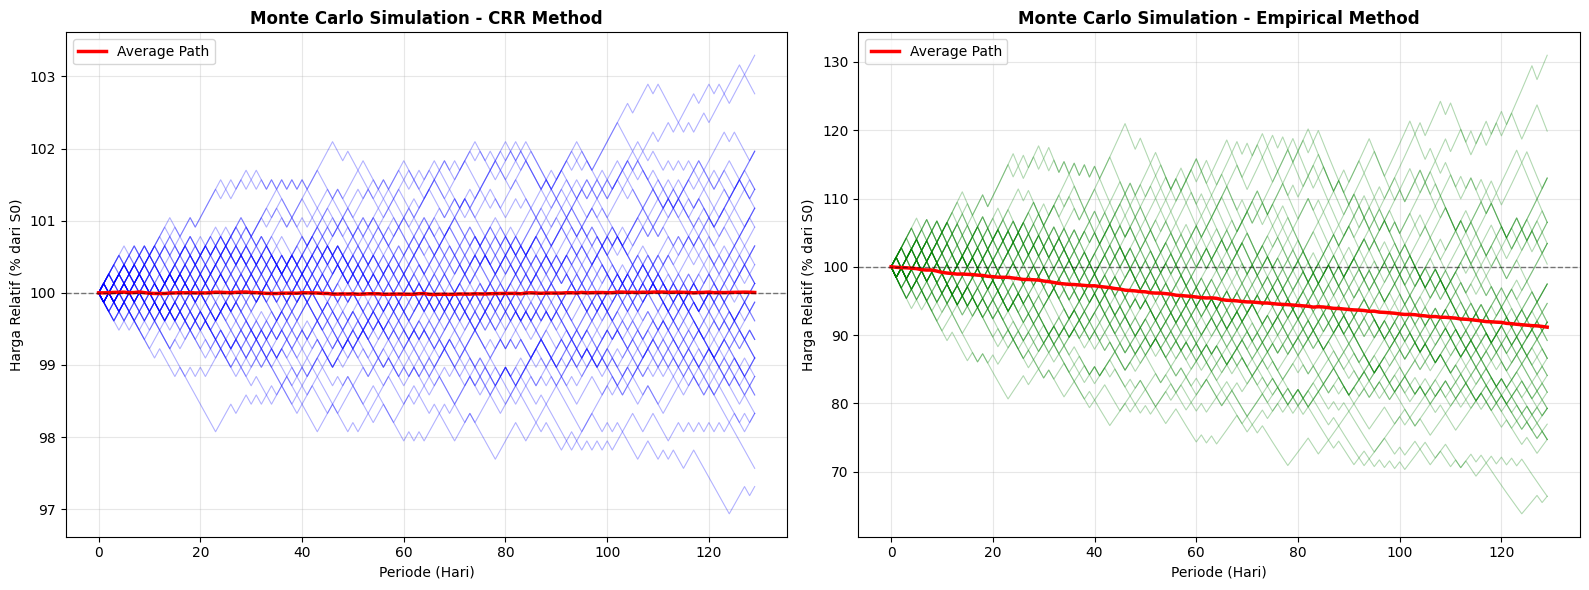

Ditampilkan 50 path dari 1000 total simulasi
Average path akhir CRR: Rp 4,030.20 (100.00% dari S0)
Average path akhir Empiris: Rp 3,673.66 (91.16% dari S0)


In [ ]:
# Hitung rata-rata dan CI terlebih dahulu
harga_mean_crr = simulasi_crr.mean(axis=0)
harga_mean_emp = simulasi_emp.mean(axis=0)

# Visualisasi beberapa path simulasi + rata-rata (pergerakan relatif terhadap S0)
num_paths = 50  # tampilkan 50 path dari 1000 simulasi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CRR Monte Carlo - normalisasi terhadap S0
for i in range(num_paths):
    ax1.plot((simulasi_crr[i] / S0) * 100, alpha=0.3, linewidth=0.8, color='blue')
ax1.plot((harga_mean_crr / S0) * 100, color='red', linewidth=2.5, label='Average Path')
ax1.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_title('Monte Carlo Simulation - CRR Method', fontweight='bold')
ax1.set_xlabel('Periode (Hari)')
ax1.set_ylabel('Harga Relatif (% dari S0)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Empiris - normalisasi terhadap S0
for i in range(num_paths):
    ax2.plot((simulasi_emp[i] / S0) * 100, alpha=0.3, linewidth=0.8, color='green')
ax2.plot((harga_mean_emp / S0) * 100, color='red', linewidth=2.5, label='Average Path')
ax2.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Monte Carlo Simulation - Empirical Method', fontweight='bold')
ax2.set_xlabel('Periode (Hari)')
ax2.set_ylabel('Harga Relatif (% dari S0)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ditampilkan {num_paths} path dari {M} total simulasi")
print(f"Average path akhir CRR: Rp {harga_mean_crr[-1]:,.2f} ({(harga_mean_crr[-1]/S0)*100:.2f}% dari S0)")
print(f"Average path akhir Empiris: Rp {harga_mean_emp[-1]:,.2f} ({(harga_mean_emp[-1]/S0)*100:.2f}% dari S0)")

## Hasil Simulasi dan Confidence Interval 95%

In [ ]:
# CRR
harga_mean_crr = simulasi_crr.mean(axis=0)
lower_ci_crr = np.percentile(simulasi_crr, 2.5, axis=0)
upper_ci_crr = np.percentile(simulasi_crr, 97.5, axis=0)

# Empiris
harga_mean_emp = simulasi_emp.mean(axis=0)
lower_ci_emp = np.percentile(simulasi_emp, 2.5, axis=0)
upper_ci_emp = np.percentile(simulasi_emp, 97.5, axis=0)

print("Harga simulasi akhir (periode ke-130):")
print(f"CRR: Rp {harga_mean_crr[-1]:,.2f} (CI: {lower_ci_crr[-1]:,.2f} - {upper_ci_crr[-1]:,.2f})")
print(f"Empiris: Rp {harga_mean_emp[-1]:,.2f} (CI: {lower_ci_emp[-1]:,.2f} - {upper_ci_emp[-1]:,.2f})")
print(f"Aktual: Rp {harga_aktual[-1]:,.2f}")

Harga simulasi akhir (periode ke-130):
CRR: Rp 4,030.20 (CI: 3,921.76 - 4,151.98)
Empiris: Rp 3,673.66 (CI: 2,597.38 - 5,124.85)
Aktual: Rp 3,470.00


## Visualisasi Simulasi Monte Carlo: CRR vs Empiris

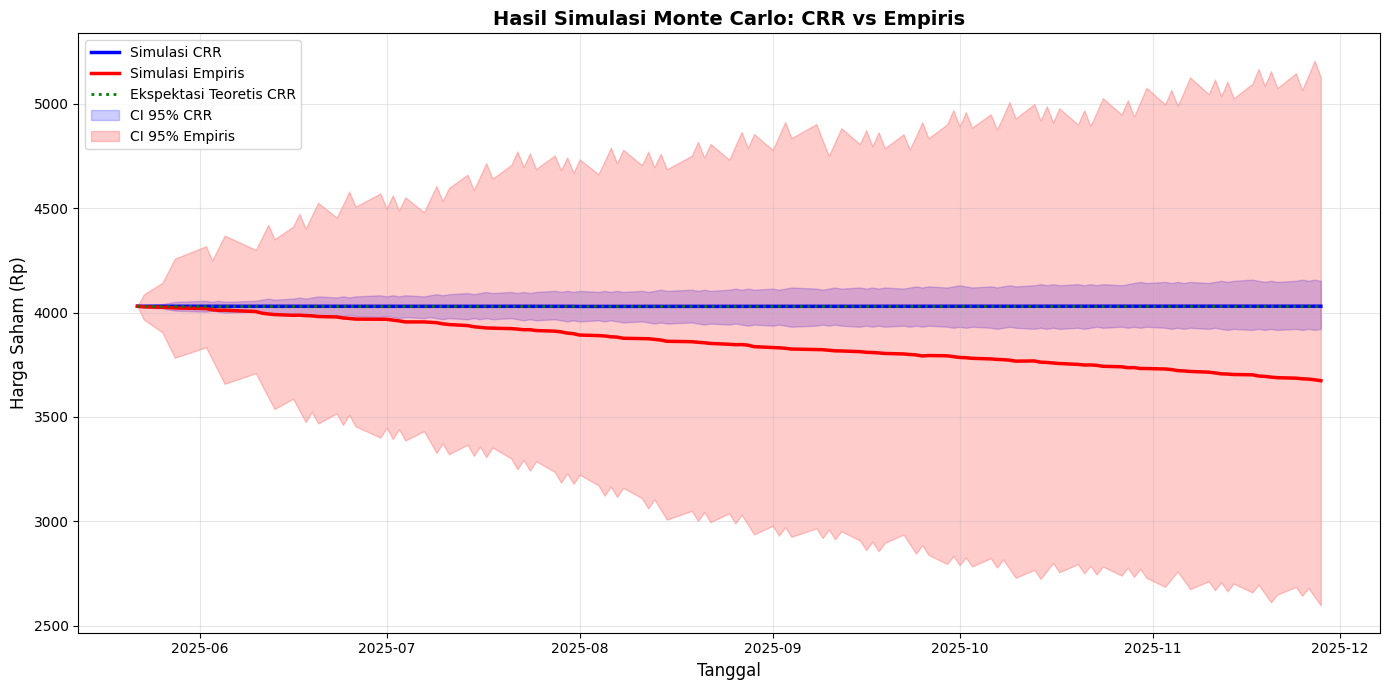

Rata-rata akhir CRR: Rp 4,030.20
Rata-rata akhir Empiris: Rp 3,673.66
Ekspektasi teoretis CRR: Rp 4,030.05


In [ ]:
plt.figure(figsize=(14,7))

plt.plot(data_test['Date'], harga_mean_crr, label='Simulasi CRR', linestyle='-', linewidth=2.5, color='blue')
plt.plot(data_test['Date'], harga_mean_emp, label='Simulasi Empiris', linestyle='-', linewidth=2.5, color='red')
plt.plot(data_test['Date'], mean_theoretical, label='Ekspektasi Teoretis CRR', linestyle=':', linewidth=2, color='green')

plt.fill_between(data_test['Date'], lower_ci_crr, upper_ci_crr, alpha=0.2, label='CI 95% CRR', color='blue')
plt.fill_between(data_test['Date'], lower_ci_emp, upper_ci_emp, alpha=0.2, label='CI 95% Empiris', color='red')

plt.title('Hasil Simulasi Monte Carlo: CRR vs Empiris', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Saham (Rp)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rata-rata akhir CRR: Rp {harga_mean_crr[-1]:,.2f}")
print(f"Rata-rata akhir Empiris: Rp {harga_mean_emp[-1]:,.2f}")
print(f"Ekspektasi teoretis CRR: Rp {mean_theoretical[-1]:,.2f}")

## Visualisasi Perbandingan: CRR vs Empiris vs Aktual

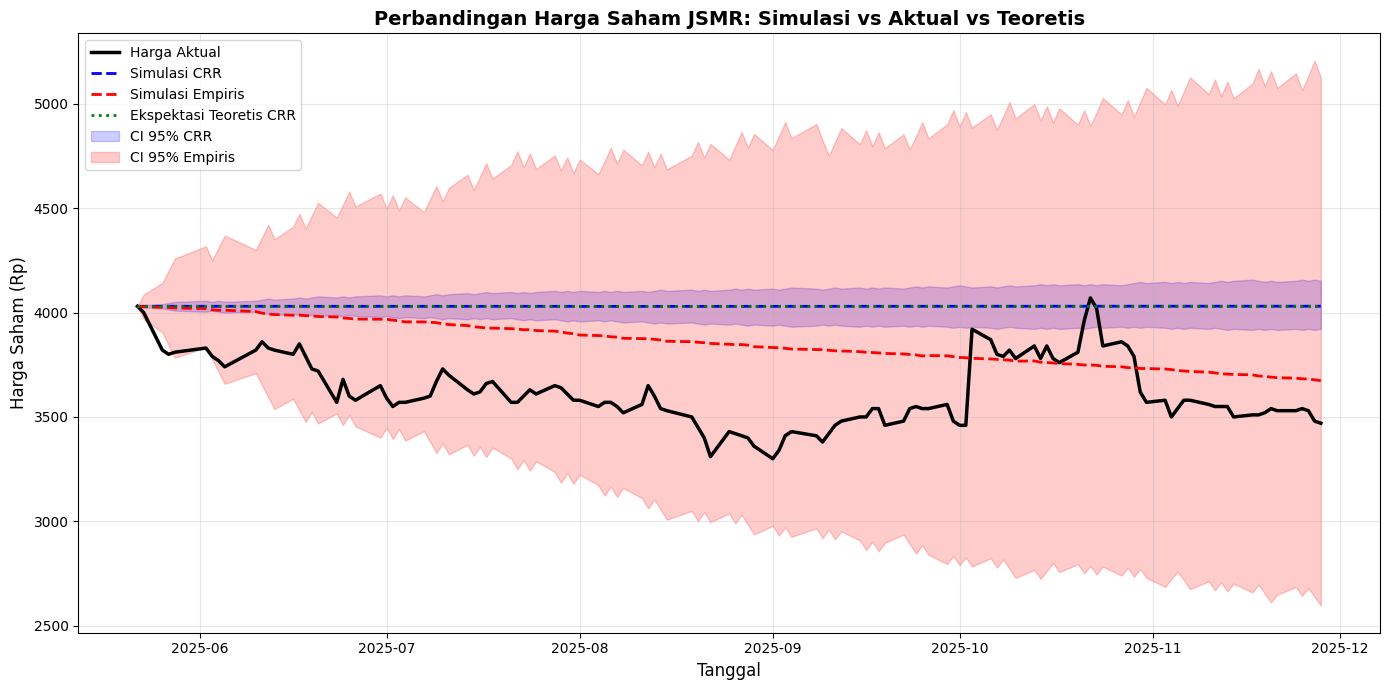

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(data_test['Date'], harga_aktual, label='Harga Aktual', linewidth=2.5, color='black')
plt.plot(data_test['Date'], harga_mean_crr, label='Simulasi CRR', linestyle='--', linewidth=2, color='blue')
plt.plot(data_test['Date'], harga_mean_emp, label='Simulasi Empiris', linestyle='--', linewidth=2, color='red')
plt.plot(data_test['Date'], mean_theoretical, label='Ekspektasi Teoretis CRR', linestyle=':', linewidth=2, color='green')

plt.fill_between(data_test['Date'], lower_ci_crr, upper_ci_crr, alpha=0.2, label='CI 95% CRR', color='blue')
plt.fill_between(data_test['Date'], lower_ci_emp, upper_ci_emp, alpha=0.2, label='CI 95% Empiris', color='red')

plt.title('Perbandingan Harga Saham JSMR: Simulasi vs Aktual vs Teoretis', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Saham (Rp)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analisis Error dan Perbandingan Metode

In [ ]:
# Hitung error
error_crr = harga_mean_crr - harga_aktual
error_emp = harga_mean_emp - harga_aktual
error_theoretical = mean_theoretical - harga_aktual

# Hitung metrics
mae_crr = np.mean(np.abs(error_crr))
mae_emp = np.mean(np.abs(error_emp))
mae_theoretical = np.mean(np.abs(error_theoretical))

mse_crr = np.mean(error_crr**2)
mse_emp = np.mean(error_emp**2)
mse_theoretical = np.mean(error_theoretical**2)

mape_crr = np.mean(np.abs(error_crr / harga_aktual)) * 100
mape_emp = np.mean(np.abs(error_emp / harga_aktual)) * 100
mape_theoretical = np.mean(np.abs(error_theoretical / harga_aktual)) * 100

print("\nPerbandingan Akurasi Metode:")
print(f"\nMAE:")
print(f"  CRR Monte Carlo: Rp {mae_crr:,.2f}")
print(f"  Empiris: Rp {mae_emp:,.2f}")
print(f"  Teoretis CRR: Rp {mae_theoretical:,.2f}")

print(f"\nMSE:")
print(f"  CRR Monte Carlo: {mse_crr:,.2f}")
print(f"  Empiris: {mse_emp:,.2f}")
print(f"  Teoretis CRR: {mse_theoretical:,.2f}")

print(f"\nMAPE:")
print(f"  CRR Monte Carlo: {mape_crr:.4f}%")
print(f"  Empiris: {mape_emp:.4f}%")
print(f"  Teoretis CRR: {mape_theoretical:.4f}%")

# Tentukan metode terbaik
if mae_crr < mae_emp and mae_crr < mae_theoretical:
    print(f"\nKesimpulan: Metode CRR Monte Carlo paling akurat dengan MAE terendah")
elif mae_emp < mae_crr and mae_emp < mae_theoretical:
    print(f"\nKesimpulan: Metode Empiris paling akurat dengan MAE terendah")
else:
    print(f"\nKesimpulan: Metode Teoretis CRR paling akurat dengan MAE terendah")


Perbandingan Akurasi Metode:

MAE:
  CRR Monte Carlo: Rp 408.95
  Empiris: Rp 253.37
  Teoretis CRR: Rp 409.10

MSE:
  CRR Monte Carlo: 192,258.76
  Empiris: 78,867.90
  Teoretis CRR: 192,443.34

MAPE:
  CRR Monte Carlo: 11.5028%
  Empiris: 7.1091%
  Teoretis CRR: 11.5073%

Kesimpulan: Metode Empiris paling akurat dengan MAE terendah


### Boxplot Perbandingan Error

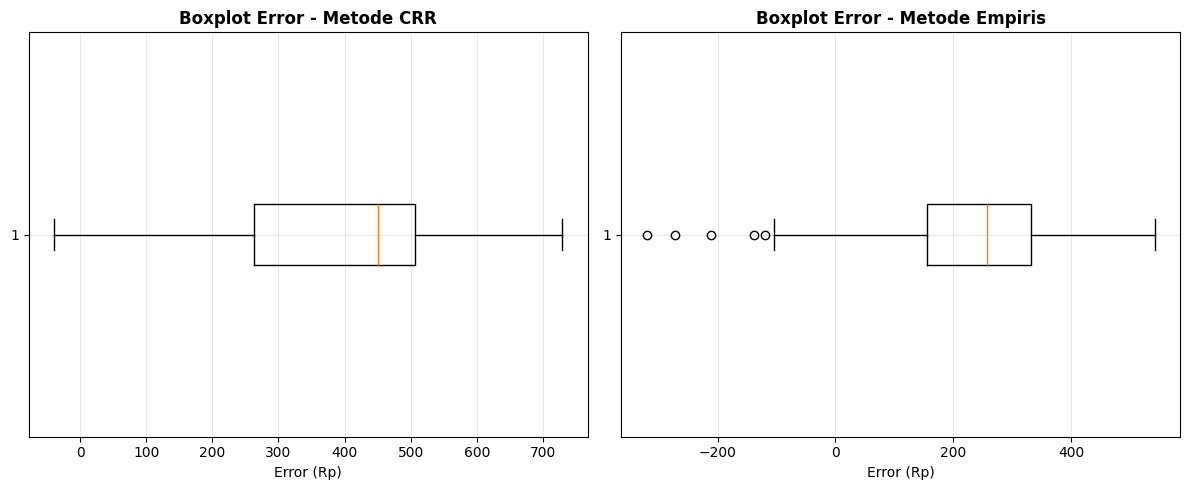

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot CRR
ax1.boxplot(error_crr, vert=False)
ax1.set_title('Boxplot Error - Metode CRR', fontweight='bold')
ax1.set_xlabel('Error (Rp)')
ax1.grid(True, alpha=0.3)

# Boxplot Empiris
ax2.boxplot(error_emp, vert=False)
ax2.set_title('Boxplot Error - Metode Empiris', fontweight='bold')
ax2.set_xlabel('Error (Rp)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Histogram Perbandingan Error

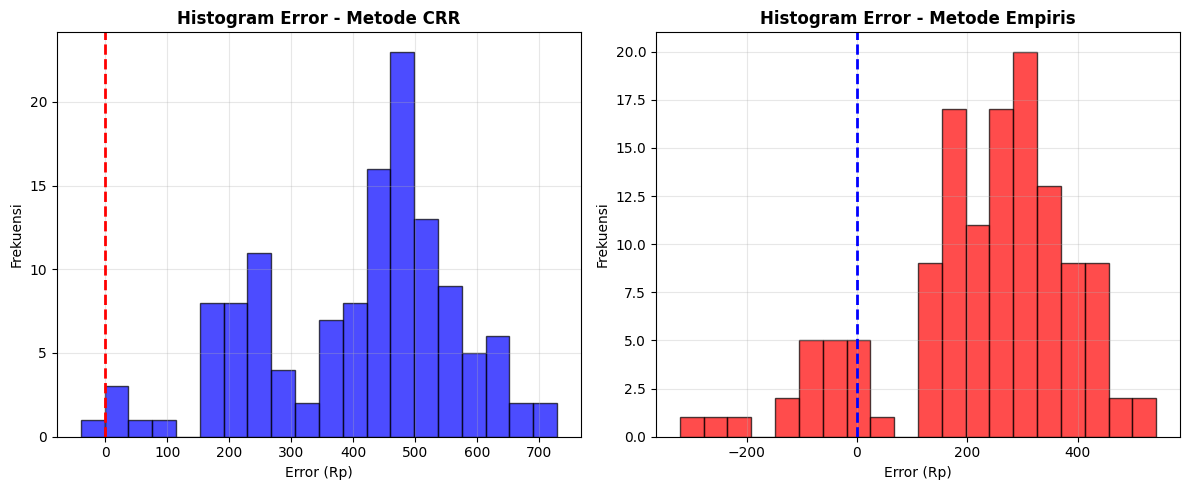

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram CRR
ax1.hist(error_crr, bins=20, color='blue', alpha=0.7, edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.set_title('Histogram Error - Metode CRR', fontweight='bold')
ax1.set_xlabel('Error (Rp)')
ax1.set_ylabel('Frekuensi')
ax1.grid(True, alpha=0.3)

# Histogram Empiris
ax2.hist(error_emp, bins=20, color='red', alpha=0.7, edgecolor='black')
ax2.axvline(0, color='blue', linestyle='--', linewidth=2)
ax2.set_title('Histogram Error - Metode Empiris', fontweight='bold')
ax2.set_xlabel('Error (Rp)')
ax2.set_ylabel('Frekuensi')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Tabel Hasil Simulasi

In [ ]:
hasil = pd.DataFrame({
    'Tanggal': data_test['Date'],
    'Harga Aktual': harga_aktual,
    'Simulasi CRR': harga_mean_crr,
    'Simulasi Empiris': harga_mean_emp,
    'Error CRR': error_crr,
    'Error Empiris': error_emp
})

print("Preview Hasil Simulasi:")
hasil.head(10)

Preview Hasil Simulasi:


,Tanggal,Harga Aktual,Simulasi CRR,Simulasi Empiris,Error CRR,Error Empiris
0,2025-05-22,4030.0,4030.000000,4030.000000,0.000000,0.000000
1,2025-05-23,4000.0,4030.003387,4027.124805,30.003387,27.124805
2,2025-05-26,3820.0,4030.079906,4025.195364,210.079906,205.195364
3,2025-05-27,3800.0,4030.239857,4023.950705,230.239857,223.950705
4,2025-05-28,3810.0,4030.326703,4021.893498,220.326703,211.893498
5,2025-06-02,3830.0,4030.371806,4019.013621,200.371806,189.013621
6,2025-06-03,3790.0,4030.092667,4013.026747,240.092667,223.026747
7,2025-06-04,3770.0,4030.169106,4010.750632,260.169106,240.750632
8,2025-06-05,3740.0,4030.465261,4011.116301,290.465261,271.116301
9,2025-06-10,3820.0,4030.145772,4004.712130,210.145772,184.712130
